In [52]:
# load necessary libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import defaultdict
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader, Sampler
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import umap
from tqdm import tqdm

# load the dictionary terms
groups_dictionary = pd.read_csv("../01_data/dictionary/groups_dictionary_cl.csv")

# load the ground truth data with augmentations
with open("../01_data/annotations/annotations_augmentations.json") as f:
    gt_augmentations = json.load(f)

In [53]:
# create a single list of all dictionary entries paired with their category
mention_list = []
category_list = []
categories = groups_dictionary.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dictionary[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)

category_list = [cat for cat in category_list]

df = pd.DataFrame({'mention': mention_list, 'category': category_list})

def duplicate_minimum(df, min_count=5):
    new_rows = []
    for cat in df['category'].unique():
        entries = df[df['category'] == cat]
        n = len(entries)
        if n < min_count:
            repeats = min_count - n
            sampled = entries.sample(repeats, replace=True)
            new_rows.append(sampled)
    if new_rows:
        df = pd.concat([df] + new_rows, ignore_index=True)
    return df

df = duplicate_minimum(df, min_count=5)

mention_list = df["mention"].to_list()
category_list = df["category"].to_list()

In [54]:
class UnbalancedDataset(Dataset):
    def __init__(self, tokenizer, cat2id, mentions, labels, max_len=64):
        self.dataset = []
        self.max_len = max_len

        for mention, label in zip(mentions, labels):
            encoding = tokenizer(
                mention,
                padding="max_length",
                truncation=True,
                max_length=self.max_len,
                return_tensors="pt"
            )

            self.dataset.append({
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0),
                "label_id": torch.tensor(cat2id[label])
            })

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

    
category_to_indices = defaultdict(list)

for idx, cat in enumerate(category_list):
    category_to_indices[cat].append(idx)

class BalancedDataset(Dataset):
    def __init__(self, mentions, labels):
        self.mentions = mentions
        self.labels = labels
    
    def __len__(self):
        return len(self.mentions)
    
    def __getitem__(self, idx):
        return self.mentions[idx], self.labels[idx]

class BalancedBatchSampler(Sampler):
    def __init__(self, category_to_indices, categories_per_batch, samples_per_category, batches_per_epoch):
        self.category_to_indices = category_to_indices
        self.categories = list(category_to_indices.keys())
        self.categories_per_batch = categories_per_batch
        self.samples_per_category = samples_per_category
        self.batches_per_epoch = batches_per_epoch

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch_indices = []
            selected_cats = random.sample(self.categories, self.categories_per_batch)
            for cat in selected_cats:
                indices = self.category_to_indices[cat]
                chosen = random.choices(indices, k=self.samples_per_category)
                batch_indices.extend(chosen)
            yield batch_indices


def collate_fn(batch):
    texts, labels = zip(*batch)
    encodings = tokenizer(list(texts), padding=True, truncation=True, return_tensors='pt')
    labels = torch.tensor([cat2id[l] for l in labels])
    return encodings['input_ids'], encodings['attention_mask'], labels

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

In [55]:
# create either BALANCED or RANDOM/UNBALANCED dataset and dataloader
dataset = BalancedDataset(mention_list, category_list)

# BALANCED
batch_sampler = BalancedBatchSampler(
    category_to_indices,
    categories_per_batch=10,
    samples_per_category=3,
    batches_per_epoch=100
)

dataloader = DataLoader(
    dataset,
    batch_sampler=batch_sampler,
    collate_fn=collate_fn
)

In [56]:
class SpanEncoder(nn.Module):
    def __init__(self, model_name="roberta-base", proj_dim=128):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        # projection head (2-layer MLP recommended)
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, proj_dim)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # mean pooling
        h = outputs.last_hidden_state.mean(dim=1)
        # cls token
        #h = outputs.last_hidden_state[:, 0]
        z = self.projector(h)
        return h, z


def supervised_contrastive_loss(embeddings, labels, temperature=0.1):
    embeddings = F.normalize(embeddings, dim=1)
    sim_matrix = torch.matmul(embeddings, embeddings.T) / temperature

    labels = labels.unsqueeze(1)
    
    mask = torch.eq(labels, labels.T).float()  # positives mask
    mask.fill_diagonal_(0)  # remove self-similarity

    pos_counts = mask.sum(1)
    valid = pos_counts > 0
    pos_counts = torch.clamp(pos_counts, min=1)

    log_prob = F.log_softmax(sim_matrix, dim=1)
    mean_log_prob_pos = (mask * log_prob).sum(1) / pos_counts
    loss = -mean_log_prob_pos[valid].mean()
    return loss

In [57]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SpanEncoder().to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

for epoch in range(50):
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Training")
    for batch in progress_bar:

        # extract all batch data
        input_ids, attention_mask, batch_labels = [x.to(device) for x in batch]
        
        #input_ids = batch["input_ids"].to(device)
        #attention_mask = batch["attention_mask"].to(device)
        #batch_labels = batch["label_id"].to(device)

        # clear the old gradient
        optimizer.zero_grad()

        # run data through the model and save the outputs, use mps with mixed precision (16 bit floating point for forward pass)
        with torch.autocast(device_type="mps", dtype=torch.float16):
            _, z = model(input_ids, attention_mask)
            # calculate the loss and add to total loss
            loss = supervised_contrastive_loss(z, batch_labels)
            total_loss += loss.item()

        # run backpropagation, cap gradients to prevent explosion
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)

        # update parameters and the progress bar
        optimizer.step()
        progress_bar.set_postfix(loss=loss.item())

    # calculate average batch loss and print it
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}, Average Batch Loss: {avg_loss:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Training:   0%|          | 0/100 [00:00<?, ?it/s]

tensor([44, 44, 44, 24, 24, 24, 35, 35, 35, 16, 16, 16, 41, 41, 41, 32, 32, 32,
         0,  0,  0, 25, 25, 25, 11, 11, 11, 36, 36, 36], device='mps:0')


Training:   1%|          | 1/100 [00:01<02:14,  1.36s/it, loss=3.3]

tensor([ 8,  8,  8,  4,  4,  4, 34, 34, 34, 21, 21, 21, 11, 11, 11, 42, 42, 42,
        13, 13, 13,  1,  1,  1, 12, 12, 12, 41, 41, 41], device='mps:0')


Training:   3%|▎         | 3/100 [00:01<00:46,  2.10it/s, loss=3.22]

...

tensor([28, 28, 28, 39, 39, 39, 24, 24, 24, 35, 35, 35,  0,  0,  0, 13, 13, 13,
        25, 25, 25, 20, 20, 20, 43, 43, 43,  5,  5,  5], device='mps:0')
tensor([ 1,  1,  1, 21, 21, 21, 36, 36, 36, 15, 15, 15, 39, 39, 39, 26, 26, 26,
         3,  3,  3, 11, 11, 11, 10, 10, 10, 42, 42, 42], device='mps:0')


Training:  20%|██        | 20/100 [00:04<00:11,  6.72it/s, loss=1.82]

tensor([44, 44, 44, 37, 37, 37,  4,  4,  4, 30, 30, 30, 39, 39, 39,  7,  7,  7,
        17, 17, 17, 29, 29, 29, 26, 26, 26, 41, 41, 41], device='mps:0')
tensor([ 3,  3,  3, 29, 29, 29,  8,  8,  8, 37, 37, 37, 44, 44, 44, 26, 26, 26,
        32, 32, 32, 27, 27, 27,  6,  6,  6, 30, 30, 30], device='mps:0')


Training:  20%|██        | 20/100 [00:04<00:18,  4.41it/s, loss=1.82]


KeyboardInterrupt: 

In [49]:
model.eval()

with torch.no_grad():
    all_embeddings = []

    for batch in dataloader:
        input_ids, attention_mask, batch_labels = [x.to(device) for x in batch]
        #input_ids = batch["input_ids"].to(device)
        #attention_mask = batch["attention_mask"].to(device)
        #batch_labels = batch["label_id"].to(device)
        h, z = model(input_ids, attention_mask)
        all_embeddings.append(z.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
labels_np = np.array([cat2id[cat] for cat in category_list])

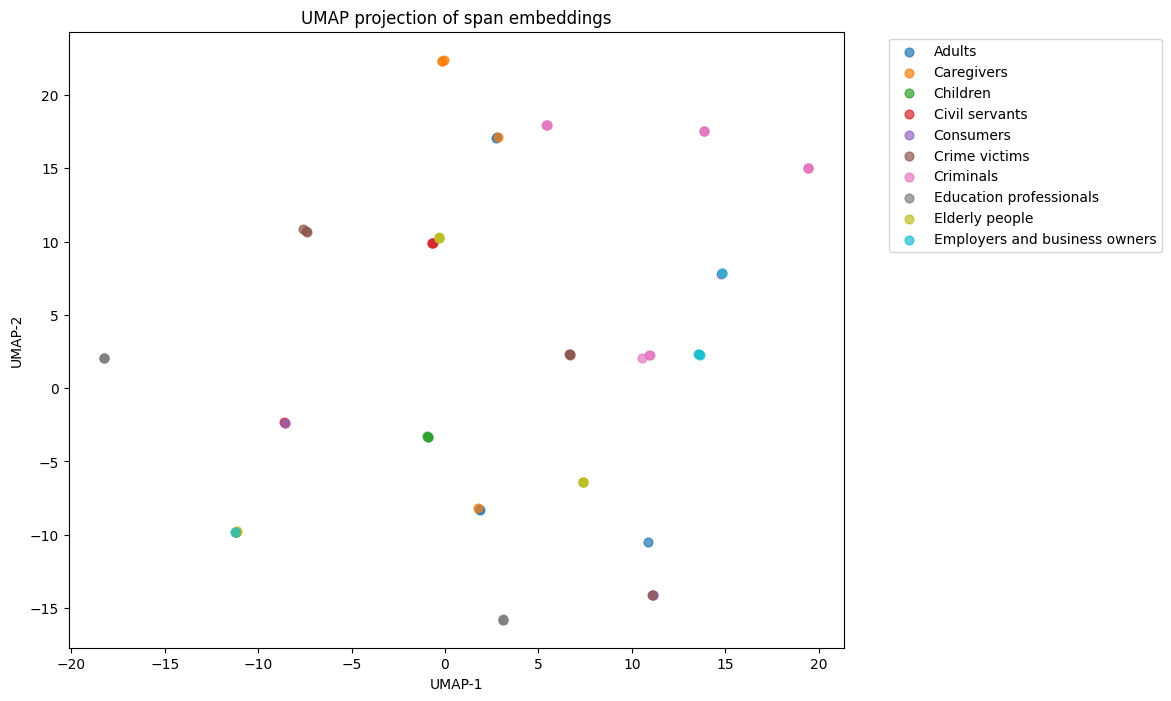

In [42]:
reducer = umap.UMAP(
    n_neighbors=15,   # controls local vs global structure
    min_dist=0.1,     # how tightly points are packed
    metric="cosine"   # best for embeddings
)

# Fit and transform
embedding_2d = reducer.fit_transform(all_embeddings)

plt.figure(figsize=(10, 8))
categories = list(cat2id.keys())
num_classes = len(categories)

for c in range(10):
    idx = np.where(labels_np == c)[0]
    if len(idx) == 0:
        continue
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        label=categories[c],
        alpha=0.7,
        s=40
    )

plt.title("UMAP projection of span embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

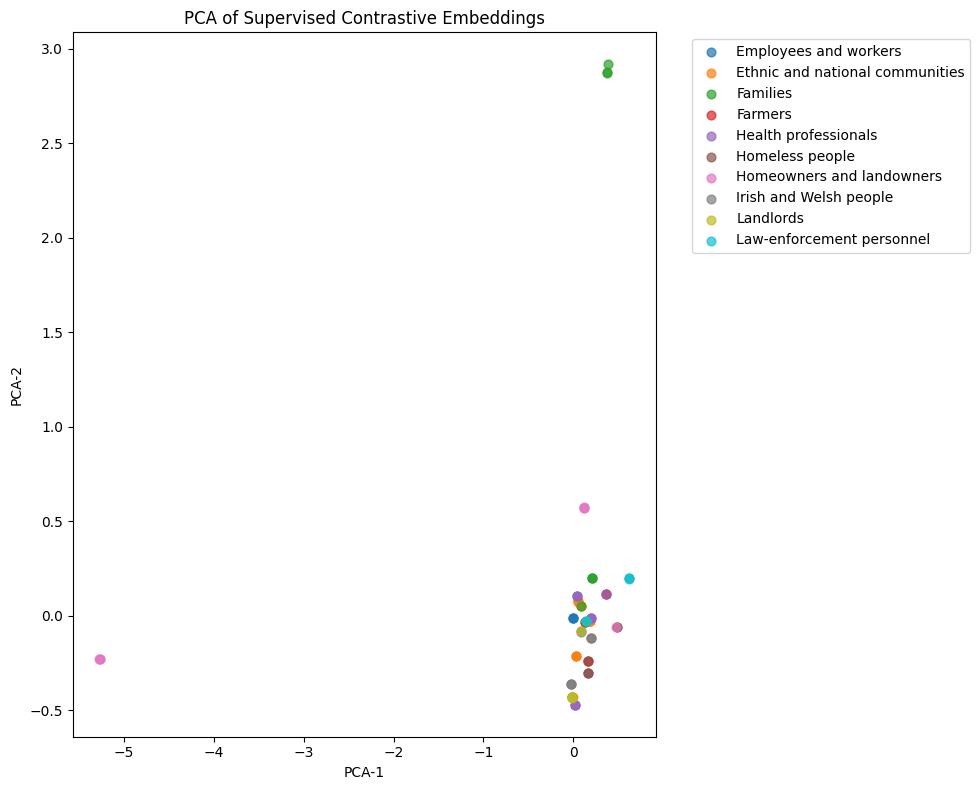

In [50]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings)


plt.figure(figsize=(10, 8))
categories = list(cat2id.keys())
num_classes = len(categories)

for c in range(10, 20):
    idx = np.where(labels_np == c)[0]
    if len(idx) == 0:
        continue
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        label=categories[c],
        alpha=0.7,
        s=40
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("PCA of Supervised Contrastive Embeddings")
plt.tight_layout()
plt.show()

In [51]:
dbscan = DBSCAN(eps=.05, min_samples=2, metric='cosine') 
labels = dbscan.fit_predict(all_embeddings)

cluster_dict = defaultdict(list)

for mention, label in zip(mention_list, labels):
    cluster_dict[label].append(mention)

for cluster_id, mentions in cluster_dict.items():
    print(f"Cluster {cluster_id} ({len(mentions)} mentions):")
    for mention in mentions:
        print(f"  - {mention}")
    print()

Cluster 0 (9 mentions):
  - adults
  - middle-aged people
  - therapists
  - parents
  - lone parents
  - farmers
  - lessors
  - policemen
  - Garda

Cluster 1 (18 mentions):
  - caregivers
  - care staff
  - care workers
  - asylum seekers
  - refugees
  - refugee children
  - sick people
  - ill people
  - care-recipients
  - people living and working in rural areas
  - rural communities
  - rural and coastal communities
  - learners
  - apprentices
  - trainees
  - public employees
  - civil servants
  - customers

Cluster 2 (9 mentions):
  - children
  - kids
  - child
  - homosexual people
  - people on low income
  - poor people
  - workers
  - employees
  - workers

Cluster 3 (9 mentions):
  - children at risk
  - pre school children
  - children of working families
  - farming community
  - primary producers
  - nurses
  - pedestrians
  - walkers
  - passengers

Cluster 4 (12 mentions):
  - civil servants
  - public servants
  - public employees
  - senior citizens
  - elderly